# Importación de librerías

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Carga de archivos (.txt) y etiquetado

In [15]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Configura las rutas.
bueno_dir = '/content/drive/MyDrive/Colab Notebooks/BUENO'
malo_dir = '/content/drive/MyDrive/Colab Notebooks/MALO'

X_features = []
y_labels = []

def cargar_datos_tiempo_real(ruta_carpeta, etiqueta):
    conteo_archivos = 0
    conteo_filas = 0
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"):
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            try:
                # Carga archivos de 14 columnas (limpiados previamente).
                df = pd.read_csv(ruta_completa, sep=' ', decimal=',', header=0)
                df = df.apply(pd.to_numeric, errors='coerce').dropna()

                # Filtra por fase: Solo usa las filas donde Aire/Muestra es 1 (Muestra).
                # En el archivo procesado por Limpiador.py, la fase está en la última columna (índice 13).
                df_muestra = df[df.iloc[:, 13] == 1]

                # Extrae solo las 13 columnas de sensores de gas (índices 0 al 12).
                for row in df_muestra.values:
                    X_features.append(row[:13])
                    y_labels.append(etiqueta)
                    conteo_filas += 1
                conteo_archivos += 1
            except Exception as e:
                print(f"Error en {archivo}: {e}")

    print(f"Carpeta {os.path.basename(ruta_carpeta)}: {conteo_archivos} archivos, {conteo_filas} filas de muestra.")

# Carga los datos.
n_buenos = cargar_datos_tiempo_real(bueno_dir, 1) # Clase Positiva
n_malos = cargar_datos_tiempo_real(malo_dir, 0)  # Clase Negativa

X = np.array(X_features)
y = np.array(y_labels)

print(f"Finalizado: {n_buenos} archivos BUENOS y {n_malos} archivos MALOS cargados.")
print(f"Forma de la matriz X: {X.shape}")

Carpeta BUENO: 62 archivos, 8235 filas de muestra.
Carpeta MALO: 82 archivos, 11084 filas de muestra.
Finalizado: None archivos BUENOS y None archivos MALOS cargados.
Forma de la matriz X: (19319, 13)


# División del Dataset (Train, Val, Test) y Escalado

In [17]:
# Realiza la primera división: Separa el 15% para el TEST FINAL.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Realiza la segunda división: Del resto (85%), separa un ~18% para obtener un 15% del total para VALIDACIÓN.
# (0.85 * 0.176 \u2248 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# Realiza el escalado estándar (Z-score).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Muestras totales: {len(X)}")
print(f"Entrenamiento: {len(X_train_scaled)} (70%)")
print(f"Validación:    {len(X_val_scaled)} (15%)")
print(f"Test Final:    {len(X_test_scaled)} (15%)")

Muestras totales: 19319
Entrenamiento: 13530 (70%)
Validación:    2891 (15%)
Test Final:    2898 (15%)


# Definición y Entrenamiento de la ANN

In [18]:
# Define el modelo.
model = Sequential([
    Dense(16, activation='relu', input_shape=(13,)),
    Dropout(0.2), # Aumenta el dropout para evitar el sobreajuste.
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Configura la parada temprana monitorizando la pérdida de VALIDACIÓN.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrena el modelo.
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val), # Usa el conjunto de validación explícito.
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6512 - loss: 0.5880 - val_accuracy: 0.8385 - val_loss: 0.3376
Epoch 2/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8316 - loss: 0.3415 - val_accuracy: 0.8561 - val_loss: 0.2747
Epoch 3/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8423 - loss: 0.3038 - val_accuracy: 0.8727 - val_loss: 0.2393
Epoch 4/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8562 - loss: 0.2755 - val_accuracy: 0.8827 - val_loss: 0.2194
Epoch 5/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8663 - loss: 0.2536 - val_accuracy: 0.8900 - val_loss: 0.2033
Epoch 6/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8781 - loss: 0.2361 - val_accuracy: 0.9028 - val_loss: 0.1931
Epoch 7/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8798 - loss: 0.2284 - val_accuracy: 0.9132 - val_loss: 0.1814
Epoch 8/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8880 - loss: 0.2145 - val_ac

# Evaluación y Resultados

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9596 - loss: 0.0798

>> PRECISIÓN FINAL EN EL TEST: 96.00%


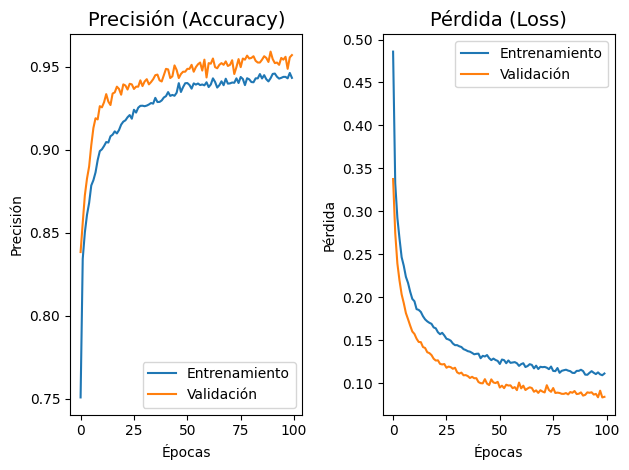

In [19]:
# Evalúa con el conjunto de Test.
loss, acc = model.evaluate(X_test_scaled, y_test)
print(f"\n>> PRECISIÓN FINAL EN EL TEST: {acc*100:.2f}%")

# Genera la gráfica de Precisión (Accuracy).
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Genera la gráfica de Pérdida (Loss).
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


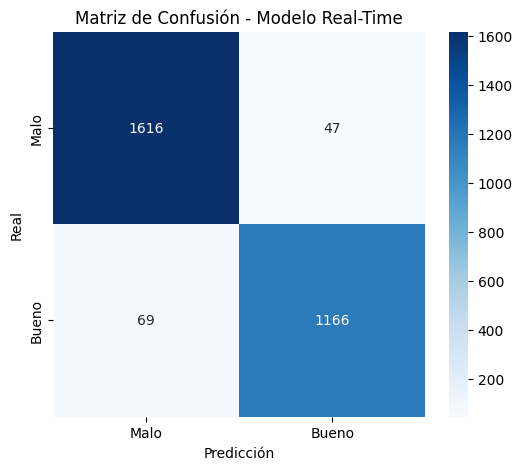

In [20]:
# Realiza predicciones en el conjunto de prueba.
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malo', 'Bueno'], yticklabels=['Malo', 'Bueno'])
plt.title('Matriz de Confusión - Modelo Real-Time')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# Exportar y guardar el modelo

In [21]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = '/content/modelo_hachis2.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"\nProceso finalizado. Descarga el archivo: {tflite_path}")

Saved artifact at '/tmp/tmp3vr2xfr4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133753627337424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133753616455568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133753616456720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133753616452688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133753616453648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133753616454608: TensorSpec(shape=(), dtype=tf.resource, name=None)

Proceso finalizado. Descarga el archivo: /content/modelo_hachis2.tflite


In [22]:
print("Medias para Flutter:", list(scaler.mean_))
print("Desviaciones para Flutter:", list(np.sqrt(scaler.var_)))

Medias para Flutter: [np.float64(1161.0118994826312), np.float64(31498.383000739097), np.float64(2.7170731707317075), np.float64(2439.326977087953), np.float64(2563.381152993348), np.float64(358.06823429416175), np.float64(337.11979526977234), np.float64(78.58594752402115), np.float64(5.393882483370421), np.float64(1.086407827050998), np.float64(438.1720620842572), np.float64(2.180192165558019), np.float64(417324.81948436174)]
Desviaciones para Flutter: [np.float64(358.44842172001654), np.float64(2092.1438423315703), np.float64(1.0346886695211017), np.float64(10653.201362780099), np.float64(10348.675181008712), np.float64(159.13467387933156), np.float64(183.83301987185445), np.float64(24.96561917292588), np.float64(0.2215315488500112), np.float64(3.7576240427003036), np.float64(41.12681291489954), np.float64(1.017390961281985), np.float64(113678.74843013866)]
